In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from tqdm import tqdm
from dateutil.relativedelta import relativedelta
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
def calculate_prediction_intervals(y_test, forecast, confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate prediction intervals using bootstrapping.

    Parameters:
    - y_test: pandas.Series, actual test values
    - forecast: pandas.Series, forecasted values
    - confidence_level: float, confidence level for prediction interval (e.g., 0.95 for 95%)
    - n_bootstrap: int, number of bootstrap samples

    Returns:
    - lower_bound: pandas.Series, lower bound of prediction interval
    - upper_bound: pandas.Series, upper bound of prediction interval
    """
    # Step 3: Calculate residuals
    residuals = y_test - forecast

    # Step 4: Bootstrapping
    bootstrap_samples = []
    for _ in range(n_bootstrap):
        sample_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        bootstrap_forecast = forecast + sample_residuals
        bootstrap_samples.append(bootstrap_forecast)

    # Step 6: Calculate prediction intervals
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100
    lower_bound = pd.Series(np.percentile(bootstrap_samples, lower_percentile, axis=0), index=forecast.index)
    gb_forecast = pd.Series(np.percentile(bootstrap_samples, 0.5, axis=0), index=forecast.index)
    upper_bound = pd.Series(np.percentile(bootstrap_samples, upper_percentile, axis=0), index=forecast.index)

    return lower_bound, gb_forecast, upper_bound

In [3]:
def calculate_oot_prediction_intervals(df, X_oot, oot_gb, target_column='price_total_agg', confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate OOT prediction intervals for out-of-time data.

    Parameters:
    - df: pandas.DataFrame, training data containing features and target
    - X_oot: pandas.DataFrame, out-of-time features
    - oot_gb: OOT model
    - target_column: str, name of the target column in df (default: 'price_total_agg')
    - n_bootstrap: int, number of bootstrap samples (default: 1000)
    - confidence_level: float, confidence level for prediction interval (default: 0.95)

    Returns:
    - oot_gb_forecast_lower: pandas.Series, lower bound of prediction interval
    - oot_gb_forecast: pandas.Series, median forecast
    - oot_gb_forecast_upper: pandas.Series, upper bound of prediction interval
    """
    # Calculate percentiles based on confidence level
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100

    bootstrap_predictions = []
    
    for _ in range(n_bootstrap):
        # Generate bootstrap sample
        df_boot = resample(df)
        X_boot = df_boot.drop(columns=[target_column])
        y_boot = df_boot[target_column]
        
        # Train a new model on the bootstrap sample
        oot_boot_gb = oot_gb
        oot_boot_gb.fit(X_boot, y_boot)
        
        # Generate predictions from the bootstrap model
        bootstrap_pred = oot_boot_gb.predict(X_oot)
        bootstrap_predictions.append(bootstrap_pred)

    # Calculate lower and upper bounds for the prediction intervals
    bootstrap_predictions = np.array(bootstrap_predictions).squeeze()
    oot_gb_forecast_lower = pd.Series(np.percentile(bootstrap_predictions, lower_percentile, axis=0), index=X_oot.index)
    oot_gb_forecast = pd.Series(np.percentile(bootstrap_predictions, 50, axis=0), index=X_oot.index)
    oot_gb_forecast_upper = pd.Series(np.percentile(bootstrap_predictions, upper_percentile, axis=0), index=X_oot.index)

    return oot_gb_forecast_lower, oot_gb_forecast, oot_gb_forecast_upper

In [4]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [5]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [6]:
LOOKBACK = 3
SEASONAL_PERIODS = (24, 24*7)
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [7]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [8]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [9]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


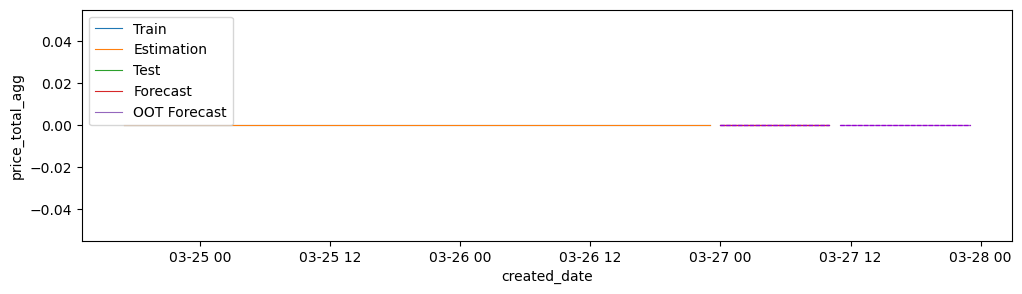

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


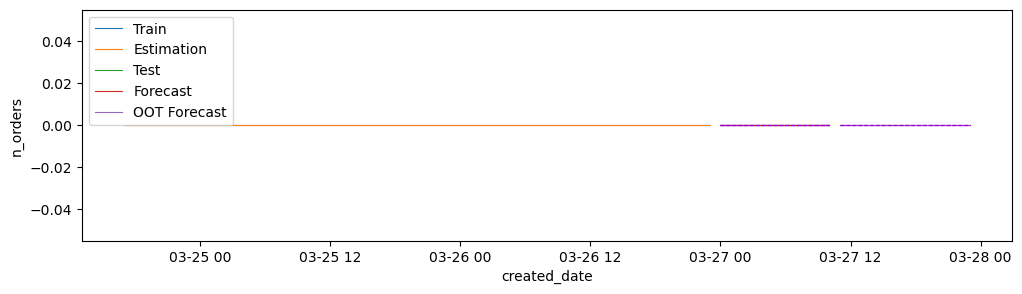

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 8266.050
train MAE:  2805.948
test RMSE: 38148.874
test MAE:  36204.631


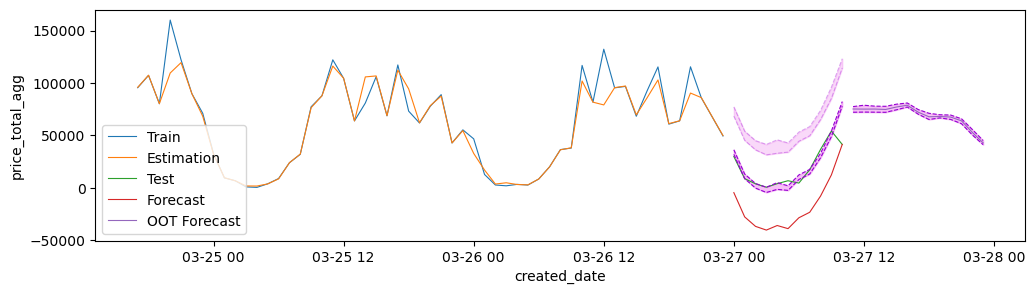

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits


KeyboardInterrupt: 

In [10]:
id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
summary_dict = {}
for account_id, sales_channel_id in tqdm(id_pairs):

    print(f'account_id: {account_id}')
    print(f'sales_channel_id: {sales_channel_id}')

    summary_dict[(account_id, sales_channel_id)] = {}

    cond = (sales['account_id'] == account_id) & (sales['sales_channel_id'] == sales_channel_id) & sales['status'].notna()
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    forecast_dict = {}

    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(col)
        
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
        
        forecast_dict[f'dataset_{n}'] = {}
        
        df = df_client_mod[col]
        
        df.fillna(0, inplace=True)
        
        lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
        df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
        
        df = df_lag.loc[df_lag.index <= END_DATE].copy()
        df_train = df_lag.loc[df_lag.index < START_DATE].copy()
        df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
        df_oot = df_lag.loc[df_lag.index > END_DATE].copy()

        X, y = df.iloc[:, 1:], df.iloc[:, 0]
        X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
        X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
        X_oot = df_oot.iloc[:, 1:]
        
        train_mad = y_train.std()
        mad = y.std()
        
        gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                            param_grid={'max_depth': [1, 2, 4, 8, 16],
                                        'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                        'max_features': ['sqrt', 'log2', None]},
                            scoring='neg_mean_absolute_error',
                            cv=TimeSeriesSplit(),
                            n_jobs=-1,
                            verbose=1)
        gscv.fit(X_train, y_train)
        gb = gscv.best_estimator_
        
        estimations = pd.Series(gb.predict(X_train), index=X_train.index)
        
        forecast = pd.Series(gb.predict(X_test), index=X_test.index)
        # forecast_lower = forecast - 0.18*train_mad
        # forecast_upper = forecast + 0.18*train_mad
        forecast_lower, forecast, forecast_upper = calculate_prediction_intervals(y_test, forecast, confidence_level=0.4, n_bootstrap=100)
        
        forecast_dict[f'dataset_{n}']['forecast'] = forecast
        forecast_dict[f'dataset_{n}']['forecast_lower'] = forecast_lower
        forecast_dict[f'dataset_{n}']['forecast_upper'] = forecast_upper
        
        forecast_dict[f'dataset_{n}']['oot_forecast'] = []
        forecast_dict[f'dataset_{n}']['oot_forecast_lower'] = []
        forecast_dict[f'dataset_{n}']['oot_forecast_upper'] = []
        
        oot_gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                                param_grid={'max_depth': [1, 2, 4, 8, 16],
                                            'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                            'max_features': ['sqrt', 'log2', None]},
                                scoring='neg_mean_absolute_error',
                                cv=TimeSeriesSplit(),
                                n_jobs=-1,
                                verbose=1)
        oot_gscv.fit(X, y)
        oot_gb = gscv.best_estimator_
        
        oot_forecast_ls = []
        oot_forecast_lower_ls = []
        oot_forecast_upper_ls = []
        for i in range(len(X_oot)):
            x_oot = X_oot.iloc[i].to_frame().T
            
            x_oot_forecast = oot_gb.predict(x_oot)[0]
            oot_forecast_ls.append(x_oot_forecast)
            # oot_forecast_lower_ls.append(x_oot_forecast - 0.18*mad)
            # oot_forecast_upper_ls.append(x_oot_forecast + 0.18*mad)
            
            for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
                X_oot.iloc[j, k] = x_oot_forecast
                
        # oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index)
        # oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
        # oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)
        
        oot_forecast_lower, oot_forecast, oot_forecast_upper = calculate_oot_prediction_intervals(df, X_oot, oot_gb, target_column=col, confidence_level=0.4, n_bootstrap=100)
        
        forecast_dict[f'dataset_{n}']['oot_forecast'] = oot_forecast
        forecast_dict[f'dataset_{n}']['oot_forecast_lower'] = oot_forecast_lower
        forecast_dict[f'dataset_{n}']['oot_forecast_upper'] = oot_forecast_upper
        
        train_pred = estimations
        train_mae = mean_absolute_error(df_train.iloc[:, 0], train_pred)
        train_rmse = root_mean_squared_error(df_train.iloc[:, 0], train_pred)

        print(f"train RMSE: {train_rmse:.3f}")
        print(f"train MAE:  {train_mae:.3f}")
        
        test_pred = forecast
        test_mae = mean_absolute_error(df_test.iloc[:, 0], test_pred)
        test_rmse = root_mean_squared_error(df_test.iloc[:, 0], test_pred)

        print(f"test RMSE: {test_rmse:.3f}")
        print(f"test MAE:  {test_mae:.3f}")
        
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
        
        plt.figure(figsize=(12, 3))
        sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
        sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
        sns.lineplot(y_test, lw=0.8, label='Test')
        sns.lineplot(forecast, lw=0.8, label='Forecast')
        sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
        sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
        sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
        sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
        plt.fill_between(x=forecast.index[-TEST_SIZE:],
                            y1=forecast_lower,
                            y2=forecast_upper,
                            color='violet',
                            alpha=0.5)
        plt.fill_between(x=forecast.index[-TEST_SIZE:],
                            y1=2*forecast_lower-forecast,
                            y2=2*forecast_upper-forecast,
                            color='violet',
                            alpha=0.3)
        plt.fill_between(x=oot_forecast.index,
                            y1=oot_forecast_lower,
                            y2=oot_forecast_upper,
                            color='violet',
                            alpha=0.5)
        plt.legend()
        plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_ml.png')
        plt.show();

    with open(f'sql/machine_learning/forecast_{account_id}_{sales_channel_id}_ml.sql', 'w') as output_file:
        pt_forecast_lower = forecast_dict['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict['dataset_1']['forecast_upper']
        no_forecast = forecast_dict['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                        channel, seller, account_id, organization_id, store_id, minutes_interval,
                                        model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
                )
        
        pt_oot_forecast_lower = forecast_dict['dataset_0']['oot_forecast_lower']
        pt_oot_forecast_upper = forecast_dict['dataset_0']['oot_forecast_upper']
        pt_oot_forecast = forecast_dict['dataset_0']['oot_forecast']
        
        no_oot_forecast_lower = forecast_dict['dataset_1']['oot_forecast_lower']
        no_oot_forecast_upper = forecast_dict['dataset_1']['oot_forecast_upper']
        no_oot_forecast = forecast_dict['dataset_1']['oot_forecast']
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                        channel, seller, account_id, organization_id, store_id, minutes_interval,
                                        model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                    VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                            {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
                            {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
                            {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
                """     
                )

In [ ]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [ ]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ml.csv', sep=';')

summary

In [ ]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

In [ ]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

In [ ]:
(train_metrics - test_metrics).abs()